<a href="https://colab.research.google.com/github/rafaelguariento/Defense_Competition_Trade_offs_Ecology_2026/blob/main/manuscript_figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Figures Generation Notebook

Codes for the figures in **Defense–Competition Trade-offs Shape Prey Eco-Evolutionary Dynamics Across Environmental Gradients** (Guariento et al., under review in *Ecology*).

In [ ]:
import os

def resolve_path(filename):
    """Return absolute save path locally for Jupyter."""
    # Assuming the notebook is in 'codes' folder
    base_dir = os.getcwd()
    # Check if we are in 'codes' folder, otherwise try to find it
    if os.path.basename(base_dir) == 'codes':
        target_dir = os.path.join(os.path.dirname(base_dir), 'novos_graficos')
    else:
        # Fallback to relative if not in 'codes'
        target_dir = os.path.join(base_dir, '..', 'novos_graficos')

    # Create directory if it doesn't exist
    os.makedirs(target_dir, exist_ok=True)
    return os.path.join(target_dir, filename)

def save_fig(fig, svg_path):
    """Save fig as SVG + PNG."""
    if svg_path is None:
        return
    try:
        fig.savefig(svg_path, bbox_inches='tight')
        fig.savefig(svg_path.replace('.svg', '.png'), dpi=300, bbox_inches='tight')
        print(f'Saved: {os.path.basename(svg_path)}')
    except Exception as e:
        print(f'Error saving {svg_path}: {e}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display
from scipy import integrate

plt.style.use('seaborn-v0_8-ticks')

PARAMS_ISO = {
    'g': 5,
    'f': 4,
    'e_p': 0.1,
    'c': 0.1,
    'd': 0.3,
    'dp': 0.2,
}

def color_fader(c1, c2, mix=0.0):
    c1 = np.array(mpl.colors.to_rgb(c1))
    c2 = np.array(mpl.colors.to_rgb(c2))
    return mpl.colors.to_hex((1 - mix) * c1 + mix * c2)

print('Loaded imports and parameters.')

Loaded imports and parameters.


## Figure 1 — Trade-off curves

Saved: Figure_1.svg


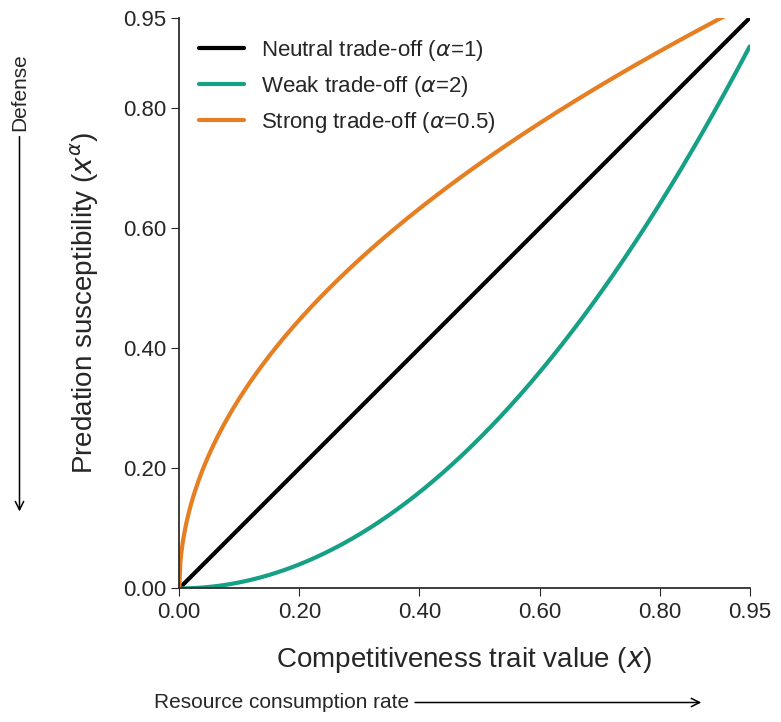

In [ ]:
def plot_direct_risk_tradeoff(curves=(1, 2, 0.5)):
    base_labels = ['Neutral trade-off', 'Weak trade-off', 'Strong trade-off']
    labels = [f'{lbl} ($\\alpha$={a:g})' for lbl, a in zip(base_labels, curves)]
    colors = ['#000000', '#16A085', '#E67E22']
    axis_label_fs, annotation_fs, tick_fs, legend_fs = 20, 15, 16, 16
    curve_lw = 3.0

    fig, ax = plt.subplots(figsize=(8, 8))
    for a, label, color in zip(curves, labels, colors):
        x = np.linspace(0, 0.95, 500)
        ax.plot(x, x ** a, label=label, color=color, linewidth=curve_lw)

    tick_values = np.array([0.00, 0.20, 0.40, 0.60, 0.80, 0.95])
    ax.set_xlim(0, 0.95); ax.set_ylim(0, 0.95)
    ax.set_xticks(tick_values); ax.set_yticks(tick_values)
    ax.set_xticklabels([f'{v:.2f}' for v in tick_values], fontsize=tick_fs)
    ax.set_yticklabels([f'{v:.2f}' for v in tick_values], fontsize=tick_fs)
    ax.set_xlabel(r'Competitiveness trait value ($x$)', labelpad=16, fontsize=axis_label_fs)
    ax.set_ylabel(r'Predation susceptibility ($x^{\alpha}$)', labelpad=16, fontsize=axis_label_fs)
    ax.annotate('Resource consumption rate',
                xy=(0.92, -0.2), xytext=(0.18, -0.2), xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.1),
                ha='center', va='center', fontsize=annotation_fs, annotation_clip=False)
    ax.annotate('Defense',
                xy=(-0.28, 0.13), xytext=(-0.28, 0.87), xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.1),
                ha='center', va='center', rotation=90, fontsize=annotation_fs, annotation_clip=False)
    ax.legend(frameon=False, fontsize=legend_fs)
    ax.set_aspect('equal', adjustable='box')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    fig.tight_layout()
    save_fig(fig, resolve_path('Figure_1.svg'))
    return fig

fig = plot_direct_risk_tradeoff()
display(fig)
plt.close(fig)


## Figure S2.1

Saved: Figure_S2_1.svg


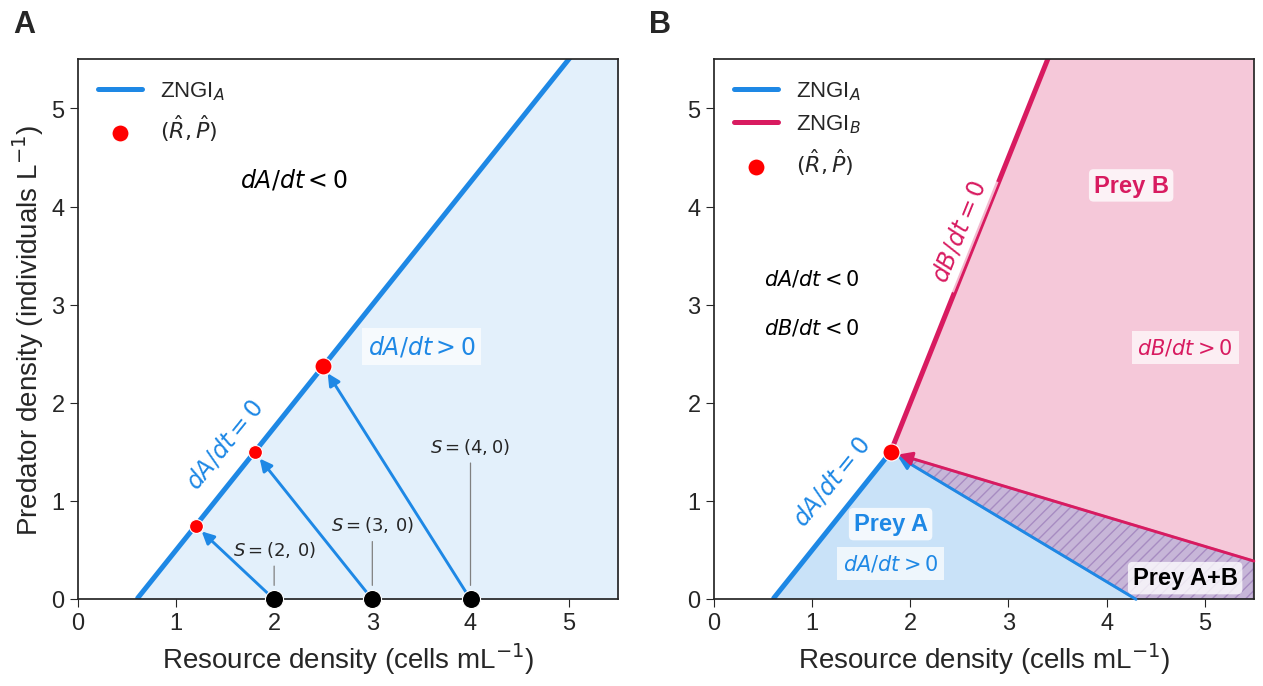

In [ ]:
def plot_figureS2_1(alpha=2):
    g_val, f_val, e_p, c_val, d_val, dp_val = (
        PARAMS_ISO['g'], PARAMS_ISO['f'], PARAMS_ISO['e_p'],
        PARAMS_ISO['c'], PARAMS_ISO['d'], PARAMS_ISO['dp']
    )

    def zngi_curve(R, x):
        return (c_val * g_val * R * x - d_val) / (e_p * f_val * x ** alpha)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6.5))
    R = np.linspace(0.01, 6, 500)
    line_lw, arrow_lw = 3.6, 3.0
    axis_label_fs, tick_fs, legend_fs, annotation_fs, panel_fs = 20, 17, 16, 17, 22
    bg_box = dict(facecolor='white', edgecolor='none', alpha=0.7)

    # Panel A
    x0 = 1.0; P0 = zngi_curve(R, x0); pos = P0 >= 0
    cA_blue = '#1E88E5'
    ax1.plot(R[pos], P0[pos], color=cA_blue, lw=line_lw, label='ZNGI$_A$')
    ax1.fill_between(R[pos], 0, P0[pos], color=cA_blue, alpha=0.12)
    ax1.text(3.5, 2.5,  r'$dA/dt > 0$', color=cA_blue, fontsize=annotation_fs, fontweight='bold', ha='center', bbox=bg_box)
    ax1.text(2.2, 4.2,  r'$dA/dt < 0$', color='black',   fontsize=annotation_fs, fontweight='bold', ha='center', bbox=bg_box)
    ax1.text(1.5, zngi_curve(1.5, x0), r'$dA/dt = 0$', color=cA_blue, fontsize=annotation_fs, fontweight='bold', ha='center', rotation=51, bbox=bg_box)

    K_show = 4.0
    ax1.scatter(K_show, 0, c='k', s=170, zorder=6, edgecolor='white', linewidth=0.8, clip_on=False)
    ax1.annotate(r'$S=(4, 0)$', xy=(K_show, 0.1), xytext=(K_show, 1.5),
                 fontsize=annotation_fs-4, ha='center',
                 arrowprops=dict(arrowstyle='-', color='gray', lw=0.9, shrinkA=3, shrinkB=3))
    R_eq, P_eq = 2.5, zngi_curve(2.5, x0)
    ax1.scatter(R_eq, P_eq, c='red', s=150, zorder=6, edgecolor='white', linewidth=0.8, label=r'$(\hat{R},\hat{P})$')
    ax1.annotate('', xy=(R_eq, P_eq), xytext=(K_show, 0),
                 arrowprops=dict(arrowstyle='-|>', color=cA_blue, lw=arrow_lw*0.7, mutation_scale=18, shrinkA=0, shrinkB=6))

    for K_extra, lbl_y in [(2.0, 0.45), (3.0, 0.7)]:
        ax1.scatter(K_extra, 0, c='k', s=170, zorder=6, edgecolor='white', linewidth=0.8, clip_on=False)
        # Fixed with raw f-string
        ax1.annotate(fr'$S=({int(K_extra)},\,0)$', xy=(K_extra, 0.1), xytext=(K_extra, lbl_y),
                     fontsize=annotation_fs-4, ha='center',
                     arrowprops=dict(arrowstyle='-', color='gray', lw=0.9, shrinkA=3, shrinkB=3))
        Req_x, Peq_x = K_extra*0.6, zngi_curve(K_extra*0.6, x0)
        ax1.scatter(Req_x, Peq_x, c='red', s=100, zorder=6, edgecolor='white', linewidth=0.8)
        ax1.annotate('', xy=(Req_x, Peq_x), xytext=(K_extra, 0),
                     arrowprops=dict(arrowstyle='-|>', color=cA_blue, lw=arrow_lw*0.7, mutation_scale=18, shrinkA=0, shrinkB=6))

    ax1.set_xlim(0, 5.5); ax1.set_ylim(0, 5.5); ax1.set_aspect('equal'); ax1.set_box_aspect(1)
    ax1.set_xticks(np.arange(0, 6, 1)); ax1.set_yticks(np.arange(0, 6, 1))
    ax1.set_xlabel('Resource density (cells mL$^{-1}$)', fontsize=axis_label_fs)
    ax1.set_ylabel('Predator density (individuals L$^{-1}$)', fontsize=axis_label_fs)
    ax1.tick_params(labelsize=tick_fs)
    ax1.legend(fontsize=legend_fs, loc='upper left', frameon=False)
    ax1.text(-0.12, 1.05, 'A', transform=ax1.transAxes, fontsize=panel_fs, fontweight='bold')

    # Panel B
    x_A, x_B, cA, cB, cAB = 1.0, 0.5, '#1E88E5', '#D81B60', '#7B52A3'
    PA = zngi_curve(R, x_A); PB = zngi_curve(R, x_B)
    posA = PA >= 0; posB = PB >= 0
    r_s = d_val*(-x_A**alpha + x_B**alpha) / (c_val*g_val*(x_A*x_B**alpha - x_B*x_A**alpha))
    p_s = zngi_curve(r_s, x_A)
    mA = (R <= r_s) & posA; mB = (R >= r_s) & posB
    sl_A = (p_s*(-(e_p*f_val)*x_A**alpha/dp_val)) / (r_s*(g_val*x_A/r_s))
    sl_B = (p_s*(-(e_p*f_val)*x_B**alpha/dp_val)) / (r_s*(g_val*x_B/r_s))

    def iv_end(slope, xmax=5.5):
        R_at_P0 = r_s - p_s/slope
        return (R_at_P0, 0.0) if R_at_P0 <= xmax else (xmax, p_s + slope*(xmax - r_s))

    eA, eB = iv_end(sl_A), iv_end(sl_B)
    R_star_A = d_val / (c_val*g_val*x_A)
    a_zone  = np.column_stack((np.concatenate(([R_star_A], R[mA], [eA[0]])), np.concatenate(([0.], PA[mA], [eA[1]]))))
    b_zone  = np.column_stack((np.concatenate(([r_s], R[mB], [eB[0]])),      np.concatenate(([p_s], PB[mB], [eB[1]]))))
    ab_zone = np.array([(r_s, p_s), eA, (eA[0], 0.), (eB[0], 0.), eB])

    ax2.add_patch(plt.Polygon(a_zone,  closed=True, fc=cA,  alpha=0.24, ec='none', zorder=0))
    ax2.add_patch(plt.Polygon(b_zone,  closed=True, fc=cB,  alpha=0.24, ec='none', zorder=0))
    ax2.add_patch(plt.Polygon(ab_zone, closed=True, fc=cAB, alpha=0.42, ec=cAB, lw=1.8, hatch='///', zorder=1))
    ax2.plot(R[mA], PA[mA], cA, lw=line_lw, label='ZNGI$_A$')
    ax2.plot(R[mB], PB[mB], cB, lw=line_lw, label='ZNGI$_B$')
    ax2.scatter(r_s, p_s, c='red', s=150, zorder=6, edgecolor='white', linewidth=0.8, label=r'$(\hat{R},\hat{P})$')
    ax2.text(1.2, zngi_curve(1.2, x_A), r'$dA/dt = 0$', color=cA, fontsize=annotation_fs, fontweight='bold', ha='center', rotation=51, bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    ax2.text(2.5, zngi_curve(2.5, x_B), r'$dB/dt = 0$', color=cB, fontsize=annotation_fs, fontweight='bold', ha='center', rotation=68, bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    ax2.text(1.8, 0.3, r'$dA/dt > 0$', color=cA,    fontsize=annotation_fs-2, fontweight='bold', ha='center', bbox=bg_box)
    ax2.text(4.8, 2.5, r'$dB/dt > 0$', color=cB,    fontsize=annotation_fs-2, fontweight='bold', ha='center', bbox=bg_box)
    ax2.text(1.0, 3.2, r'$dA/dt < 0$', color='black', fontsize=annotation_fs-2, fontweight='bold', ha='center', bbox=bg_box)
    ax2.text(1.0, 2.7, r'$dB/dt < 0$', color='black', fontsize=annotation_fs-2, fontweight='bold', ha='center', bbox=bg_box)
    ax2.annotate('', xy=(r_s, p_s), xytext=eA, arrowprops=dict(arrowstyle='-|>', color=cA, lw=arrow_lw*0.7, mutation_scale=20, shrinkA=0, shrinkB=6))
    ax2.annotate('', xy=(r_s, p_s), xytext=eB, arrowprops=dict(arrowstyle='-|>', color=cB, lw=arrow_lw*0.7, mutation_scale=20, shrinkA=0, shrinkB=6))
    lbox = dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.78)
    ax2.text(1.8, 0.7,  'Prey A',   fontsize=annotation_fs, color=cA,     fontweight='bold', ha='center', bbox=lbox)
    ax2.text(4.25, 4.15,'Prey B',   fontsize=annotation_fs, color=cB,     fontweight='bold', ha='center', bbox=lbox)
    ax2.text(4.8, 0.15, 'Prey A+B', fontsize=annotation_fs, color='black', fontweight='bold', ha='center', bbox=lbox)
    ax2.set_xlim(0, 5.5); ax2.set_ylim(0, 5.5); ax2.set_aspect('equal'); ax2.set_box_aspect(1)
    ax2.set_xticks(np.arange(0, 6, 1)); ax2.set_yticks(np.arange(0, 6, 1))
    ax2.set_xlabel('Resource density (cells mL$^{-1}$)', fontsize=axis_label_fs)
    ax2.tick_params(axis='both', labelsize=tick_fs, labelleft=True)
    ax2.legend(fontsize=legend_fs, loc='upper left', frameon=False)
    ax2.text(-0.12, 1.05, 'B', transform=ax2.transAxes, fontsize=panel_fs, fontweight='bold')
    fig.tight_layout()
    save_fig(fig, resolve_path('Figure_S2_1.svg'))
    return fig

fig = plot_figureS2_1()
display(fig)
plt.close(fig)

## Figure 2

Saved: Figure_2.svg


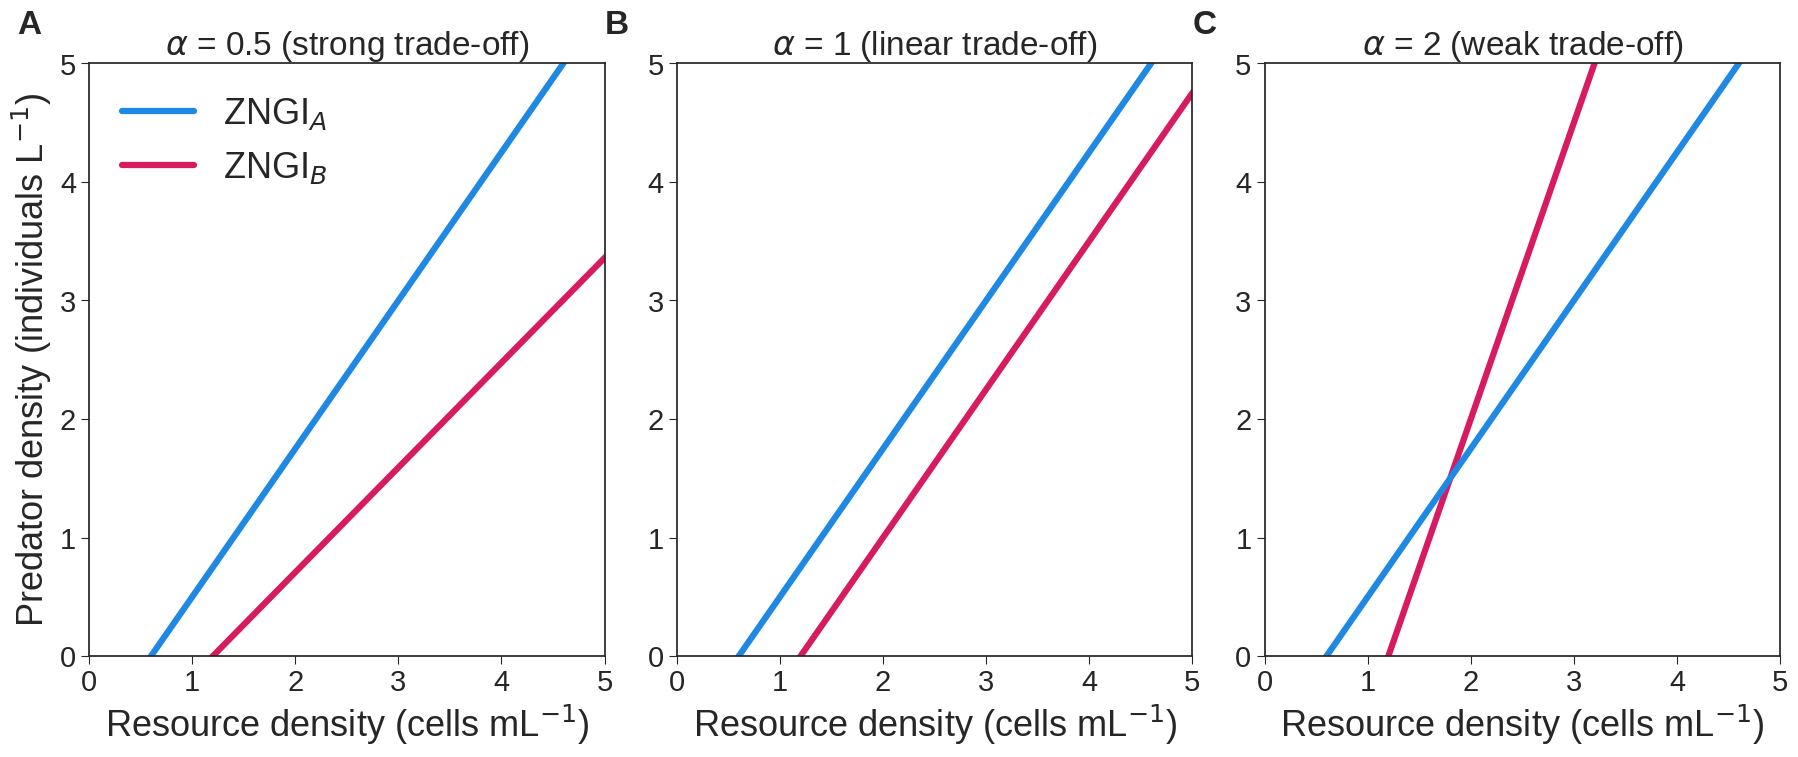

In [ ]:
def plot_zngi_by_alpha(a_values=(0.5, 1, 2), zngi_number=2):
    pop_colors = ['#D81B60', '#1E88E5']
    g, f, e_p, c, d = PARAMS_ISO['g'], PARAMS_ISO['f'], PARAMS_ISO['e_p'], PARAMS_ISO['c'], PARAMS_ISO['d']
    R = np.linspace(0.01, 10, 100)
    fig, axes = plt.subplots(1, 3, figsize=(18, 7.8))

    for idx, (ax, alpha) in enumerate(zip(axes, a_values)):
        for x in range(1, zngi_number + 1):
            frac = x / zngi_number
            zngi = (c*g*R*frac - d) / (e_p*f*frac**alpha)
            pop_label = r'ZNGI$_A$' if x == zngi_number else r'ZNGI$_B$'
            ax.plot(R, zngi, color=pop_colors[x-1], linewidth=4.5, label=pop_label)
        ax.set_ylim([0, 5]); ax.set_xlim([0, 5])
        desc = {0.5: 'strong trade-off', 1: 'linear trade-off', 2: 'weak trade-off'}.get(alpha, '')
        ax.set_title(r'$\alpha$ = ' + f'{alpha}' + (f' ({desc})' if desc else ''), fontsize=24)
        ax.set_xlabel('Resource density (cells mL$^{-1}$)', fontsize=26)
        if idx == 0:
            ax.set_ylabel('Predator density (individuals L$^{-1}$)', fontsize=26)
        ax.tick_params(axis='both', which='major', labelsize=21)
        ax.set_box_aspect(1.15)
        ax.text(-0.14, 1.05, chr(65+idx), transform=ax.transAxes, fontsize=24, fontweight='bold')
        if idx == 0:
            handles, lbls = ax.get_legend_handles_labels()
            order = [lbls.index(r'ZNGI$_A$'), lbls.index(r'ZNGI$_B$')]
            ax.legend([handles[i] for i in order], [lbls[i] for i in order], fontsize=26)

    fig.tight_layout()
    save_fig(fig, resolve_path('Figure_2.svg'))
    return fig

fig = plot_zngi_by_alpha()
display(fig)
plt.close(fig)


## Figure 3

Saved: Figure_3.svg


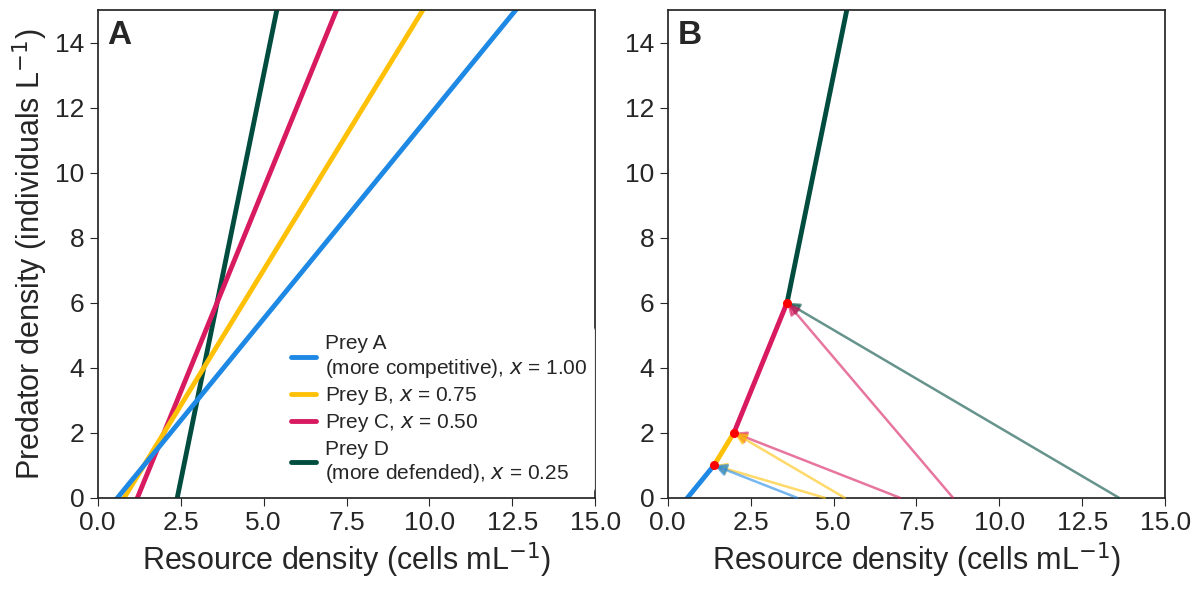

In [ ]:
def plot_outermost_zngi_and_impacts(zngi_number=4, alpha=2):
    # Synced categorical palette
    prey_colors_all = ['#004D40', '#D81B60', '#FFC107', '#1E88E5']
    # Map x_fractions to colors for impact vectors
    prey_color_map = {1.0: '#1E88E5', 0.75: '#FFC107', 0.5: '#D81B60', 0.25: '#004D40'}
    g, f, e_p, c, d, dp = PARAMS_ISO['g'], PARAMS_ISO['f'], PARAMS_ISO['e_p'], PARAMS_ISO['c'], PARAMS_ISO['d'], PARAMS_ISO['dp']
    prey_labels_all = ['Prey D', 'Prey C', 'Prey B', 'Prey A']
    line_lw, impact_lw = 3.5, 1.8

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    R1 = np.linspace(0, 14, 100)
    for x in range(1, zngi_number + 1):
        frac = x / zngi_number
        zngi = (c*g*R1*frac - d) / ((e_p*f)*(frac**alpha))
        if x == 1:               lbl = f'{prey_labels_all[x-1]}\n(more defended), $x$ = {frac:.2f}'
        elif x == zngi_number:   lbl = f'{prey_labels_all[x-1]}\n(more competitive), $x$ = {frac:.2f}'
        else:                    lbl = f'{prey_labels_all[x-1]}, $x$ = {frac:.2f}'
        ax1.plot(R1, zngi, color=prey_colors_all[x-1], linewidth=line_lw, label=lbl)

    ax1.set_ylim([0, 15]); ax1.set_xlim([0, 15])
    ax1.set_xlabel('Resource density (cells mL$^{-1}$)', fontsize=22)
    ax1.set_ylabel('Predator density (individuals L$^{-1}$)', fontsize=22)
    ax1.tick_params(axis='both', which='major', labelsize=19)
    ax1.text(0.02, 0.98, 'A', transform=ax1.transAxes, fontsize=24, fontweight='bold',
             verticalalignment='top', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    handles, lbls = ax1.get_legend_handles_labels()
    oh, ol = [], []
    for target in ['Prey A', 'Prey B', 'Prey C', 'Prey D']:
        for h, l in zip(handles, lbls):
            if l.startswith(target): oh.append(h); ol.append(l); break
    ax1.legend(oh, ol, loc='lower right', bbox_to_anchor=(1.02, -0.01),
               fontsize=15, frameon=True, facecolor='white', edgecolor='none',
               framealpha=0.9, borderpad=0.35, labelspacing=0.25, handlelength=1.2, handletextpad=0.45)

    R2 = np.linspace(0.01, 14, 1000)
    zngis2 = [(c*g*R2*(x/zngi_number) - d) / ((e_p*f)*((x/zngi_number)**alpha)) for x in range(1, zngi_number+1)]
    outermost = np.maximum.reduce(zngis2)
    for i, zngi in enumerate(zngis2):
        mask = zngi == outermost
        idx_arr = np.where(mask)[0]
        if len(idx_arr) > 0:
            mask[max(idx_arr[0]-1, 0)] = True
            mask[min(idx_arr[-1]+1, len(mask)-1)] = True
        ax2.plot(R2[mask], zngi[mask], color=prey_colors_all[i], linewidth=line_lw)

    ax2.set_ylim([0, 15]); ax2.set_xlim([0, 15])
    ax2.set_xlabel('Resource density (cells mL$^{-1}$)', fontsize=22)
    ax2.tick_params(axis='both', which='major', labelsize=19)
    ax2.text(0.02, 0.98, 'B', transform=ax2.transAxes, fontsize=24, fontweight='bold',
             verticalalignment='top', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    star_values = pd.DataFrame(columns=['index', 'RStar', 'PStar', 'x_value_1', 'x_value_2'])
    cnt = 0
    for x in range(1, zngi_number + 1):
        xv1 = x / zngi_number
        for w in range(x + 1, zngi_number + 1):
            xv2 = w / zngi_number
            rs = d*(-xv1**alpha + xv2**alpha) / (c*g*(xv1*xv2**alpha - xv2*xv1**alpha))
            ps = (c*g*rs*xv1 - d) / ((e_p*f)*xv1**alpha)
            cnt += 1
            star_values.loc[cnt] = [cnt, rs, ps, xv1, xv2]

    outers = star_values.loc[(star_values['PStar'] >= np.min(outermost)) & (star_values['PStar'] <= np.max(outermost))]
    sel = outers.iloc[[0, 3, 5]] if len(outers) >= 6 else outers
    for _, row in sel.iterrows():
        ax2.scatter(row['RStar'], row['PStar'], color='red', s=30, zorder=5)
        for xv in [row['x_value_1'], row['x_value_2']]:
            er = row['RStar'] * (1 + (g*xv/row['RStar'])*10)
            ep = row['PStar'] * (1 + (-(e_p*f)*xv**alpha/dp)*10)
            dx, dy = er - row['RStar'], ep - row['PStar']
            t_clip = 1.0
            for ev, delta, c0 in [(0, dx, row['RStar']), (15, dx, row['RStar']), (0, dy, row['PStar']), (15, dy, row['PStar'])]:
                if delta == 0: continue
                te = (ev - c0) / delta
                if te > 0 and ((delta > 0 and ev in (15,)) or (delta < 0 and ev == 0)):
                    t_clip = min(t_clip, te)
            ax2.annotate('', xy=(row['RStar'], row['PStar']),
                         xytext=(row['RStar'] + dx*t_clip, row['PStar'] + dy*t_clip),
                         arrowprops=dict(arrowstyle='-|>', color=prey_color_map.get(xv, 'gray'),
                                        lw=impact_lw, mutation_scale=18, shrinkA=0, shrinkB=0, alpha=0.6))

    fig.tight_layout()
    save_fig(fig, resolve_path('Figure_3.svg'))
    return fig

fig = plot_outermost_zngi_and_impacts()
display(fig)
plt.close(fig)


## Figure 3 — Colored version (Panel B with coexistence zones)

Saved: Figure_3_colored.svg


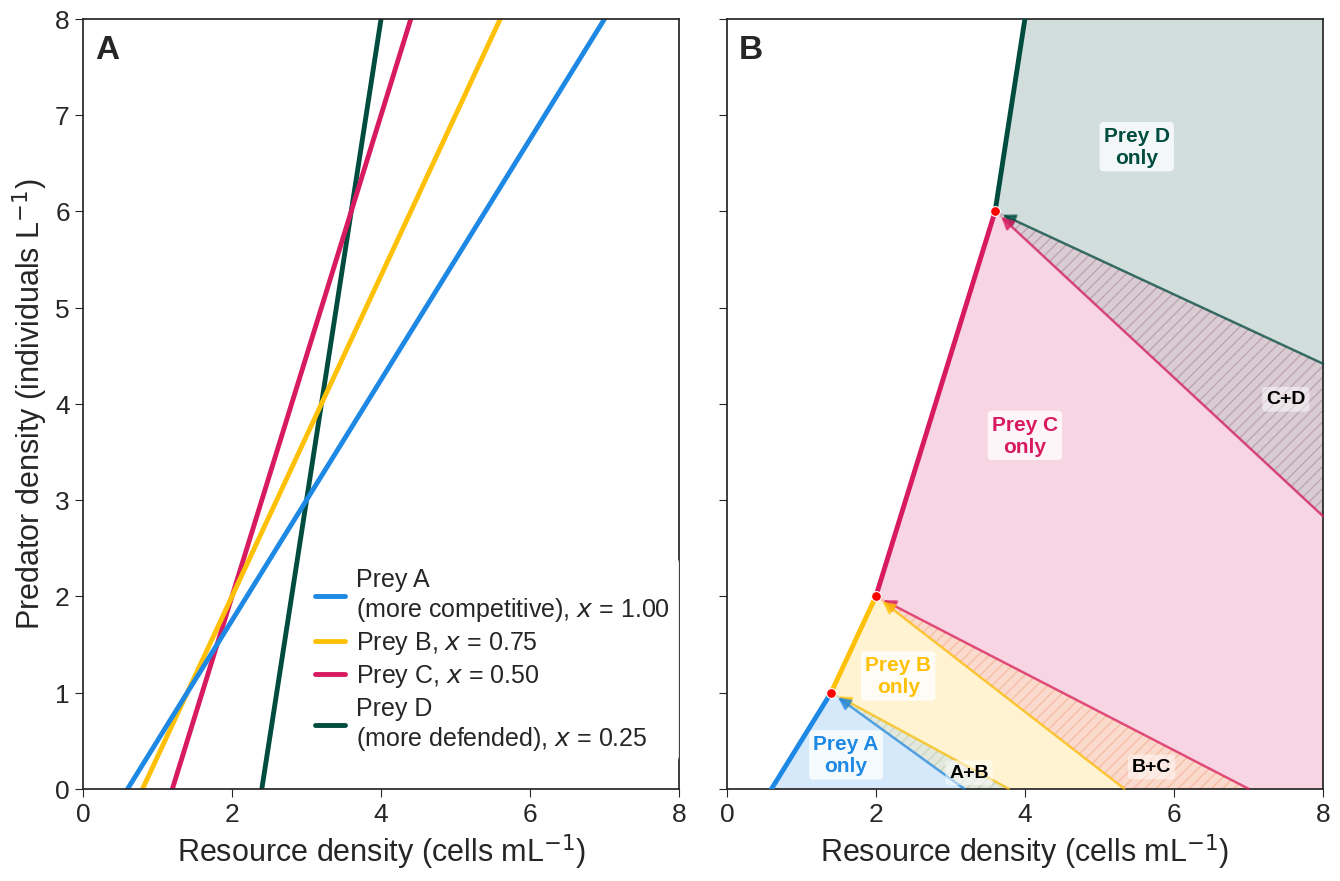

In [ ]:
def plot_outermost_zngi_colored(zngi_number=4, alpha=2):
    g, f, e_p, c, d, dp = (PARAMS_ISO['g'], PARAMS_ISO['f'], PARAMS_ISO['e_p'],
                            PARAMS_ISO['c'], PARAMS_ISO['d'], PARAMS_ISO['dp'])
    prey_labels_all = ['Prey D', 'Prey C', 'Prey B', 'Prey A']
    prey_colors_all = ['#004D40', '#D81B60', '#FFC107', '#1E88E5']
    line_lw, impact_lw = 3.5, 1.8
    x_vals = [i / zngi_number for i in range(1, zngi_number + 1)]

    def zngi(R, x):
        return (c * g * R * x - d) / ((e_p * f) * (x ** alpha))
    def R_star(x):
        return d / (c * g * x)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
    R1 = np.linspace(0, 8, 500)
    for ix, x in enumerate(x_vals):
        z = zngi(R1, x)
        if ix == 0: lbl = f'{prey_labels_all[ix]}\n(more defended), $x$ = {x:.2f}'
        elif ix == zngi_number - 1: lbl = f'{prey_labels_all[ix]}\n(more competitive), $x$ = {x:.2f}'
        else: lbl = f'{prey_labels_all[ix]}, $x$ = {x:.2f}'
        ax1.plot(R1, z, color=prey_colors_all[ix], linewidth=line_lw, label=lbl)
    ax1.set_ylim(0, 8); ax1.set_xlim(0, 8)
    ax1.set_xlabel('Resource density (cells mL$^{-1}$)', fontsize=22)
    ax1.set_ylabel('Predator density (individuals L$^{-1}$)', fontsize=22)
    ax1.tick_params(axis='both', which='major', labelsize=19)
    ax1.text(0.02, 0.98, 'A', transform=ax1.transAxes, fontsize=24, fontweight='bold',
             verticalalignment='top', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    handles, lbls = ax1.get_legend_handles_labels()
    oh, ol = [], []
    for target in ['Prey A', 'Prey B', 'Prey C', 'Prey D']:
        for h, l in zip(handles, lbls):
            if l.startswith(target): oh.append(h); ol.append(l); break
    ax1.legend(oh, ol, loc='lower right', bbox_to_anchor=(1.02, 0.02),
               fontsize=18, frameon=True, facecolor='white', edgecolor='none',
               framealpha=0.9, borderpad=0.35, labelspacing=0.25, handlelength=1.2, handletextpad=0.45)

    R2 = np.linspace(0.01, 8, 2000)
    zngis = [zngi(R2, x) for x in x_vals]
    outermost = np.maximum.reduce(zngis)
    owner = np.argmax(np.array(zngis), axis=0)
    crossings = []
    for i in range(zngi_number):
        xi = x_vals[i]
        for j in range(i + 1, zngi_number):
            xj = x_vals[j]
            denom = c * g * (xi * xj ** alpha - xj * xi ** alpha)
            if abs(denom) < 1e-14: continue
            rs = d * (-xi ** alpha + xj ** alpha) / denom
            if rs < 0 or rs > 8: continue
            ps = zngi(rs, xi)
            if ps < 0: continue
            env_here = max(zngi(rs, xv) for xv in x_vals)
            if abs(ps - env_here) < 1e-6: crossings.append((rs, ps, i, j))
    crossings.sort(key=lambda t: t[0])

    def iv_slope(x, rs, ps):
        dR, dP = g * x, e_p * f * x ** alpha
        return -(dP / dp) / (dR / rs) if abs(dR) > 1e-14 else -1e6
    def iv_endpoint(rs, ps, slope, Rmax=8, Pmax=8):
        if abs(slope) < 1e-14: return (Rmax, ps)
        R_at_P0 = rs - ps / slope
        if 0 <= R_at_P0 <= Rmax and slope < 0: return (R_at_P0, 0.0)
        P_at_Rmax = ps + slope * (Rmax - rs)
        if 0 <= P_at_Rmax <= Pmax: return (Rmax, P_at_Rmax)
        return (Rmax, 0.0)

    Rmax, Pmax = 8, 8
    iv_ends = []
    for (rs, ps, li, ri) in crossings:
        sl_left, sl_right = iv_slope(x_vals[li], rs, ps), iv_slope(x_vals[ri], rs, ps)
        iv_ends.append((iv_endpoint(rs, ps, sl_left), iv_endpoint(rs, ps, sl_right)))

    for k, (rs, ps, li, ri) in enumerate(crossings):
        ep_left, ep_right = iv_ends[k]
        coex_color = color_fader(prey_colors_all[li], prey_colors_all[ri], 0.5)
        coex_pts = [(rs, ps), ep_left]
        if ep_left[1] > 0.01 and ep_right[1] > 0.01: coex_pts.append((Rmax, 0.0))
        elif ep_left[1] > 0.01: coex_pts.extend([(Rmax, 0.0), (ep_right[0], 0.0)])
        elif ep_right[1] > 0.01: coex_pts.extend([(ep_left[0], 0.0), (Rmax, 0.0)])
        else: coex_pts.extend([(ep_left[0], 0.0), (ep_right[0], 0.0)])
        coex_pts.append(ep_right)
        ax2.add_patch(plt.Polygon(np.array(coex_pts), closed=True, fc=coex_color, alpha=0.25, ec=coex_color, lw=1.2, hatch='///', zorder=0))

    seg_boundaries = [('start', R_star(x_vals[owner[0]]), 0.0, owner[0])]
    for k, (rs, ps, li, ri) in enumerate(crossings): seg_boundaries.append(('cross', rs, ps, k))
    seg_boundaries.append(('end', Rmax, None, None))

    for s in range(len(seg_boundaries) - 1):
        sb, se = seg_boundaries[s], seg_boundaries[s+1]
        if sb[0] == 'start':
            R_lo, P_lo, prey_idx = sb[1], 0.0, sb[3]
            R_hi, P_hi, ep_hi = (se[1], se[2], iv_ends[se[3]][1]) if se[0] == 'cross' else (Rmax, zngi(Rmax, x_vals[prey_idx]), (Rmax, 0.0))
            mask = (R2 >= R_lo) & (R2 <= R_hi)
            Rseg = R2[mask]; Pseg = np.clip([zngi(r, x_vals[prey_idx]) for r in Rseg], 0, Pmax)
            poly = np.column_stack((np.concatenate(([R_lo], Rseg, [ep_hi[0]])), np.concatenate(([0.0],  Pseg, [ep_hi[1]]))))
            ax2.add_patch(plt.Polygon(poly, closed=True, fc=prey_colors_all[prey_idx], alpha=0.18, ec='none', zorder=0))
        elif sb[0] == 'cross':
            rs_lo, ps_lo, p_idx, ep_lo = sb[1], sb[2], crossings[sb[3]][2], iv_ends[sb[3]][0]
            rs_hi, ep_hi = (se[1], iv_ends[se[3]][1]) if se[0] == 'cross' else (Rmax, (Rmax, 0.0))
            mask = (R2 >= rs_lo) & (R2 <= rs_hi)
            Rseg = R2[mask]; Pseg = np.clip([zngi(r, x_vals[p_idx]) for r in Rseg], 0, Pmax)
            poly_pts = [(rs_lo, ps_lo)] + list(zip(Rseg, Pseg))
            if se[0] == 'cross': poly_pts.append((se[1], se[2]))
            poly_pts.append(ep_hi)
            if ep_hi[1] > 0.01: poly_pts.append((Rmax, 0.0))
            poly_pts.append(ep_lo)
            ax2.add_patch(plt.Polygon(np.array(poly_pts), closed=True, fc=prey_colors_all[p_idx], alpha=0.18, ec='none', zorder=0))

    for i, z in enumerate(zngis):
        mask = np.array(z) >= outermost - 1e-8
        idx_arr = np.where(mask)[0]
        if len(idx_arr) == 0: continue
        mask[max(idx_arr[0]-1,0)] = mask[min(idx_arr[-1]+1, len(mask)-1)] = True
        ax2.plot(R2[mask], np.array(z)[mask], color=prey_colors_all[i], linewidth=line_lw, zorder=3)

    for k, (rs, ps, li, ri) in enumerate(crossings):
        ax2.scatter(rs, ps, color='red', s=50, zorder=6, edgecolor='white', linewidth=0.8)
        for ep_pt, pidx in [(iv_ends[k][0], li), (iv_ends[k][1], ri)]:
            ax2.annotate('', xy=(rs, ps), xytext=ep_pt, arrowprops=dict(arrowstyle='-|>', color=prey_colors_all[pidx], lw=impact_lw, mutation_scale=18, shrinkA=0, shrinkB=6, alpha=0.7), zorder=4)

    lb = dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.78)
    lb2 = dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.5)
    if len(crossings) >= 3:
        ax2.text(1.6, 0.18, 'Prey A\nonly', fontsize=15, color=prey_colors_all[3], fontweight='bold', ha='center', bbox=lb, zorder=5)
        ax2.text(3.25, 0.12, 'A+B', fontsize=14, color='black', fontweight='bold', ha='center', bbox=lb2, zorder=5)
        ax2.text(2.3, 1.0, 'Prey B\nonly', fontsize=15, color=prey_colors_all[2], fontweight='bold', ha='center', bbox=lb, zorder=5)
        ax2.text(5.7, 0.18, 'B+C', fontsize=14, color='black', fontweight='bold', ha='center', bbox=lb2, zorder=5)
        ax2.text(4.0, 3.5, 'Prey C\nonly', fontsize=15, color=prey_colors_all[1], fontweight='bold', ha='center', bbox=lb, zorder=5)
        ax2.text(7.5, 4.0, 'C+D', fontsize=14, color='black', fontweight='bold', ha='center', bbox=lb2, zorder=5)
        ax2.text(5.5, 6.5, 'Prey D\nonly', fontsize=15, color=prey_colors_all[0], fontweight='bold', ha='center', bbox=lb, zorder=5)

    ax2.set_ylim(0, 8); ax2.set_xlim(0, 8)
    ax2.set_xlabel('Resource density (cells mL$^{-1}$)', fontsize=22)
    ax2.tick_params(axis='both', which='major', labelsize=19, labelleft=False)
    ax2.text(0.02, 0.98, 'B', transform=ax2.transAxes, fontsize=24, fontweight='bold',
             verticalalignment='top', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    plt.subplots_adjust(wspace=0.08)
    save_fig(fig, resolve_path('Figure_3_colored.svg'))
    return fig

fig = plot_outermost_zngi_colored()
display(fig)
plt.close(fig)


## Figure S2.2

Saved: Figure_S2_2.svg


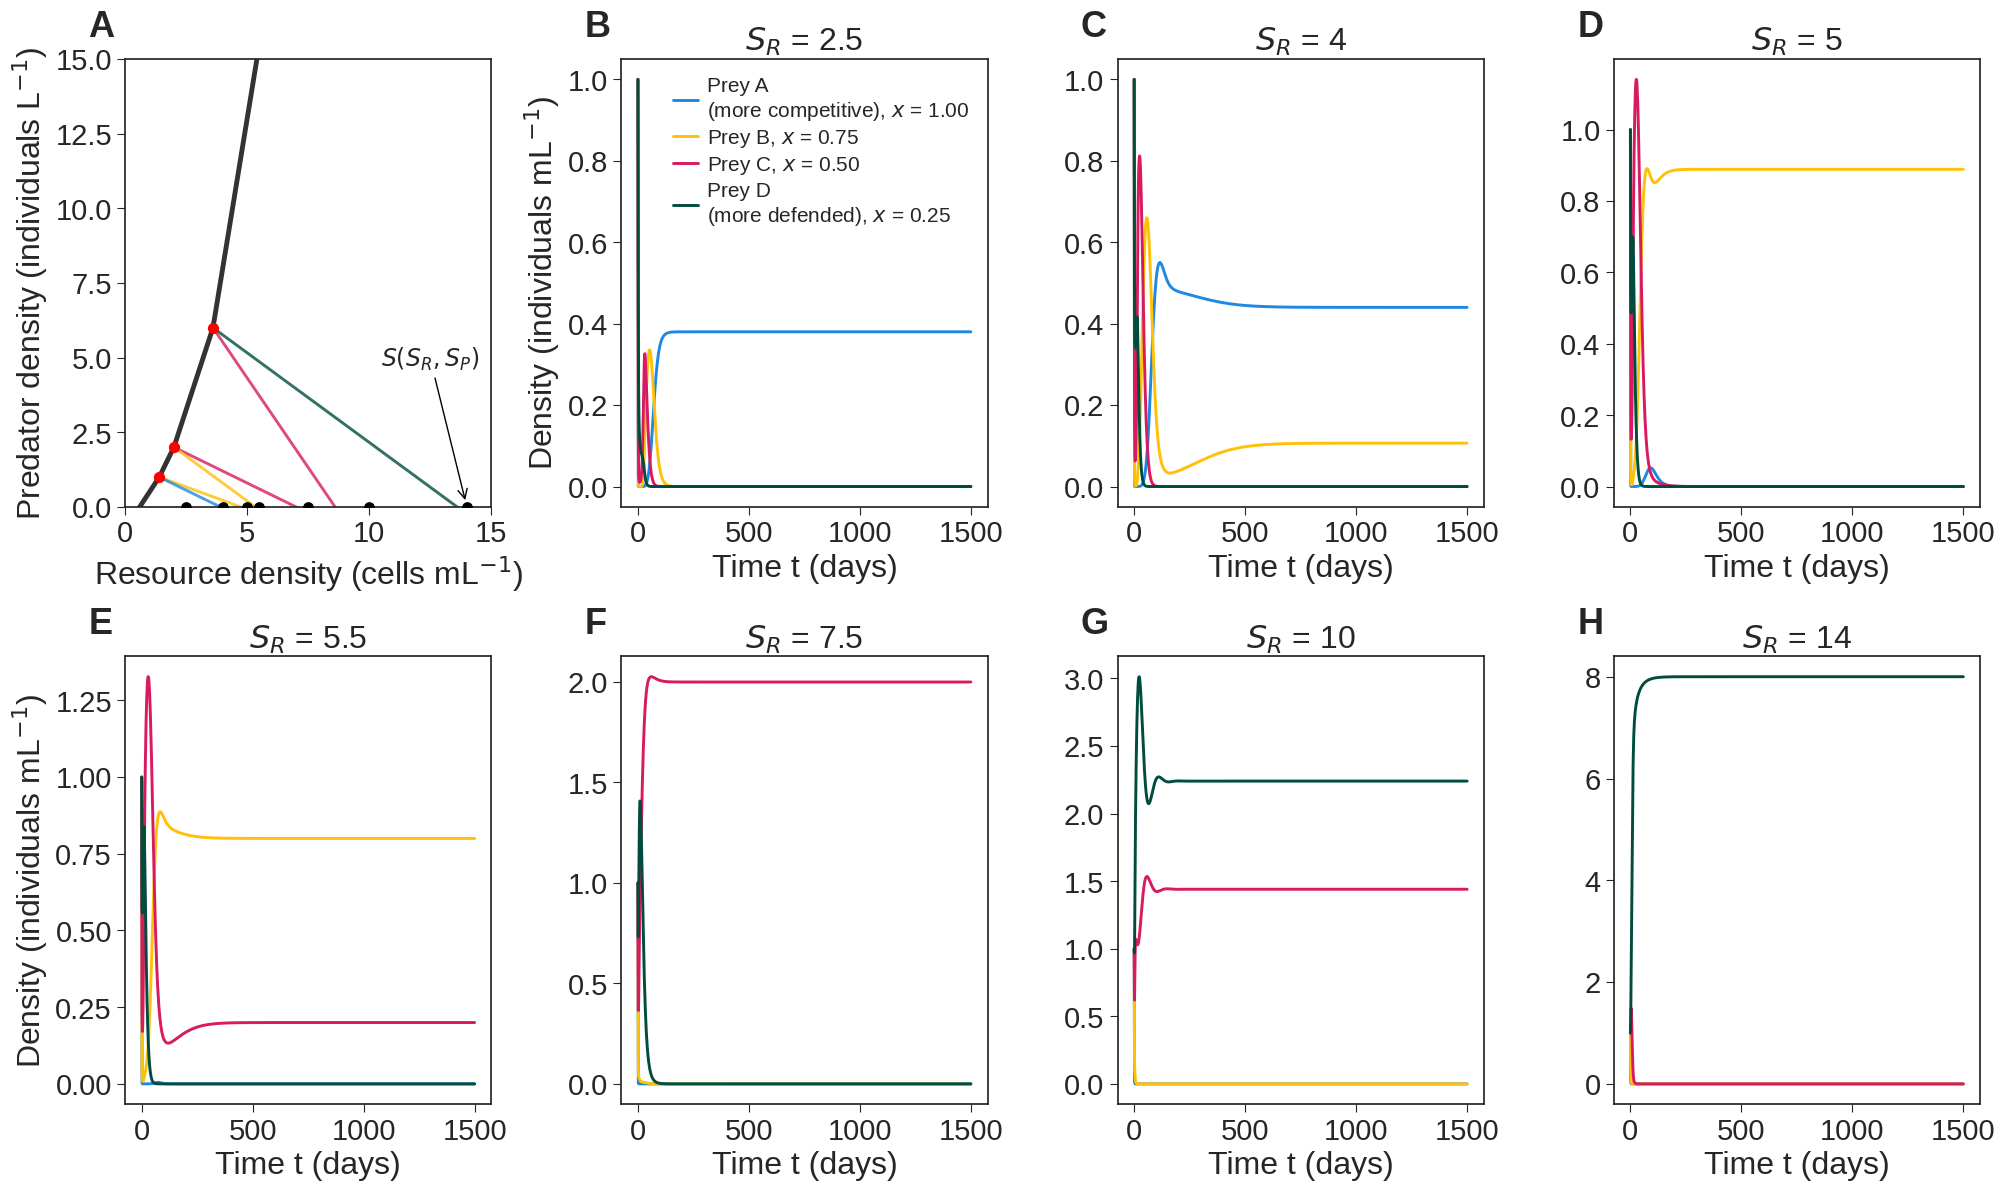

In [ ]:
def _ode_model(X, t, alpha, x1, x2, x3, x4, c, g, f, e_p, d, dp, K, r, IZ):
    n1, n2, n3, n4, R, P = X
    return [
        n1*(g*c*x1*R - f*x1**alpha*P - d),
        n2*(g*c*x2*R - f*x2**alpha*P - d),
        n3*(g*c*x3*R - f*x3**alpha*P - d),
        n4*(g*c*x4*R - f*x4**alpha*P - d),
        r*(K - R)*R - g*R*(x1*n1 + x2*n2 + x3*n3 + x4*n4),
        P*(e_p*f*(x1**alpha*n1 + x2**alpha*n2 + x3**alpha*n3 + x4**alpha*n4) - dp),
    ]

def _run_sim(K, Nt=1000, tmax=1500):
    t = np.linspace(0.0, tmax, Nt)
    res = integrate.odeint(_ode_model, [1.0, 1.0, 1.0, 1.0, K, 1.0], t,
                           args=(2, 1.0, 0.75, 0.5, 0.25, 0.1, 5, 4, 0.1, 0.3, 0.2, K, 1, 0.0))
    return t, res

def plot_timeseries_by_K(K_values=(2.5, 4, 5, 5.5, 7.5, 10, 14)):
    prey_cols = ['#1E88E5', '#FFC107', '#D81B60', '#004D40']
    prey_color_map = {1.0: '#1E88E5', 0.75: '#FFC107', 0.5: '#D81B60', 0.25: '#004D40'}
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    axes = axes.flatten(); curve_lw = 2.1
    legend_fs, title_fs, axis_label_fs, tick_fs, annotation_fs, panel_fs = 20, 23, 23, 21, 17, 26

    g_i, f_i, e_p_i, c_i, d_i, dp_i, alpha_i, n_i = 5, 4, 0.1, 0.1, 0.3, 0.2, 2, 4
    R_i = np.linspace(0.01, 10, 100)
    zngis_i = [(c_i*g_i*R_i*(x/n_i) - d_i) / (e_p_i*f_i*(x/n_i)**alpha_i) for x in range(1, n_i+1)]
    outer_i = np.maximum.reduce(zngis_i)
    axes[0].plot(R_i, outer_i, color='#333333', linewidth=3.5)
    axes[0].set_ylim([0, 15]); axes[0].set_xlim([0, 15])
    axes[0].set_xlabel('Resource density (cells mL$^{-1}$)', fontsize=axis_label_fs)
    axes[0].set_ylabel('Predator density (individuals L$^{-1}$)', fontsize=axis_label_fs)
    axes[0].tick_params(axis='both', which='major', labelsize=tick_fs)
    for K in K_values: axes[0].scatter(K, 0, color='black', s=45, zorder=5)
    axes[0].annotate(r'$S(S_R, S_P)$', xy=(14, 0), xytext=(12.5, 4.5), fontsize=annotation_fs, ha='center', va='bottom', arrowprops=dict(arrowstyle='->', color='black', lw=1, shrinkB=5))

    star_i = []
    for x in range(1, n_i+1):
        xv1 = x/n_i
        for w in range(x+1, n_i+1):
            xv2 = w/n_i
            rs = d_i*(-xv1**alpha_i + xv2**alpha_i) / (c_i*g_i*(xv1*xv2**alpha_i - xv2*xv1**alpha_i))
            ps = (c_i*g_i*rs*xv1 - d_i) / (e_p_i*f_i*xv1**alpha_i)
            star_i.append((len(star_i)+1, rs, ps, xv1, xv2))
    star_df_i = pd.DataFrame(star_i, columns=['index', 'RStar', 'PStar', 'x_value_1', 'x_value_2'])
    sel_i = star_df_i[(star_df_i['PStar'] >= np.min(outer_i)) & (star_df_i['PStar'] <= np.max(outer_i))].iloc[[0, 3, 5]]
    for _, row in sel_i.iterrows():
        axes[0].scatter(row['RStar'], row['PStar'], color='red', s=50, zorder=5)
        for xv in [row['x_value_1'], row['x_value_2']]:
            axes[0].plot([row['RStar'], row['RStar']*(1 + g_i*xv/row['RStar']*10)], [row['PStar'], row['PStar']*(1 + -(e_p_i*f_i)*xv**alpha_i/dp_i*10)], color=prey_color_map.get(xv, 'gray'), linewidth=curve_lw, alpha=0.8)
    axes[0].text(-0.1, 1.05, 'A', transform=axes[0].transAxes, fontsize=panel_fs, fontweight='bold')

    x_fracs = [1.0, 0.75, 0.5, 0.25]
    prey_lbls = [f'Prey A\n(more competitive), $x$ = {x_fracs[0]:.2f}', f'Prey B, $x$ = {x_fracs[1]:.2f}', f'Prey C, $x$ = {x_fracs[2]:.2f}', f'Prey D\n(more defended), $x$ = {x_fracs[3]:.2f}']
    for i, K in enumerate(K_values):
        ax = axes[i+1]; t_sim, res = _run_sim(K)
        for j, data in enumerate(res.T[:4]): ax.plot(t_sim, data, color=prey_cols[j], linewidth=curve_lw, label=prey_lbls[j])
        ax.set_title(f'$S_R$ = {K}', fontsize=title_fs)
        ax.set_xlabel('Time t (days)', fontsize=axis_label_fs)
        if i == 0 or i == 3: ax.set_ylabel('Density (individuals mL$^{-1}$)', fontsize=axis_label_fs)
        ax.tick_params(axis='both', which='major', labelsize=tick_fs)
        if i == 0: ax.legend(fontsize=int(legend_fs*0.75), frameon=True, facecolor='white', edgecolor='none', framealpha=0.9, borderpad=0.35, labelspacing=0.25, handlelength=1.2, handletextpad=0.45)
        ax.text(-0.1, 1.05, chr(66+i), transform=ax.transAxes, fontsize=panel_fs, fontweight='bold')
    fig.tight_layout()
    save_fig(fig, resolve_path('Figure_S2_2.svg'))
    return fig

fig = plot_timeseries_by_K()
display(fig)
plt.close(fig)


## Figure 4

Saved: Figure_4.svg


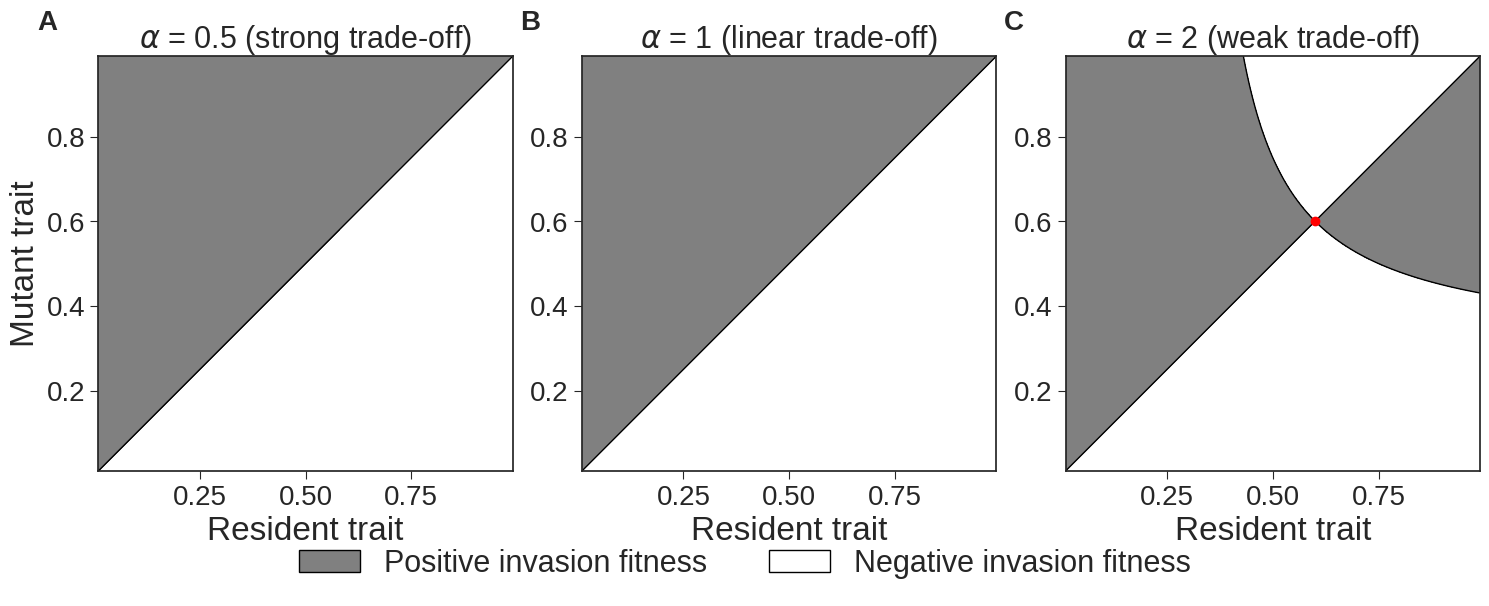

In [ ]:
def plot_pip():
    from matplotlib.colors import ListedColormap
    g, f, e_p, c, d, R_val = 5, 4, 0.1, 0.1, 0.3, 2
    def _fitness(x, y, alpha): return g*c*y*R_val - e_p*f*y**alpha*(R_val*c*g*x - d)/(e_p*f*x**alpha) - d
    x = np.linspace(0.01, 0.99, 400); y = np.linspace(0.01, 0.99, 400); X, Y = np.meshgrid(x, y)
    fig, axes = plt.subplots(1, 3, figsize=(15, 6.2))
    for idx, (ax, alpha) in enumerate(zip(axes, [0.5, 1, 2])):
        Z = _fitness(X, Y, alpha) - _fitness(X, X, alpha)
        ax.contourf(X, Y, Z, levels=np.linspace(Z.min(), 0, 100), cmap=ListedColormap(['white']))
        ax.contourf(X, Y, Z, levels=np.linspace(0, Z.max(), 100), cmap=ListedColormap(['grey']))
        ax.contour(X, Y, Z, levels=[0], colors='black', linewidths=1)
        hp = None
        for i in range(1, Z.shape[0]-1):
            for j in range(1, Z.shape[1]-1):
                if Z[i,j] == 0 and Z[i-1,j] < 0 and Z[i+1,j] < 0 and Z[i,j-1] > 0 and Z[i,j+1] > 0:
                    hp = (x[j], y[i]); break
        if hp: ax.plot(hp[0], hp[1], 'ro', markersize=6)
        ax.set_xlabel('Resident trait', fontsize=24)
        if idx == 0: ax.set_ylabel('Mutant trait', fontsize=24)
        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.set_title(r'$\alpha$ = ' + f'{alpha}' + (f" ({ {0.5: 'strong', 1: 'linear', 2: 'weak'}.get(alpha) } trade-off)" if alpha in [0.5,1,2] else ''), fontsize=22)
        ax.text(-0.1, 1.05, chr(65+idx), transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='right')
    fig.legend([plt.Rectangle((0,0),1,1,edgecolor='black',facecolor='grey'), plt.Rectangle((0,0),1,1,edgecolor='black',facecolor='white')], ['Positive invasion fitness', 'Negative invasion fitness'], loc='lower center', ncol=2, fontsize=22, frameon=False)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    save_fig(fig, resolve_path('Figure_4.svg'))
    return fig
fig = plot_pip()
display(fig)
plt.close(fig)


## Supplementary Figure S4

Saved: Figure_S4.svg


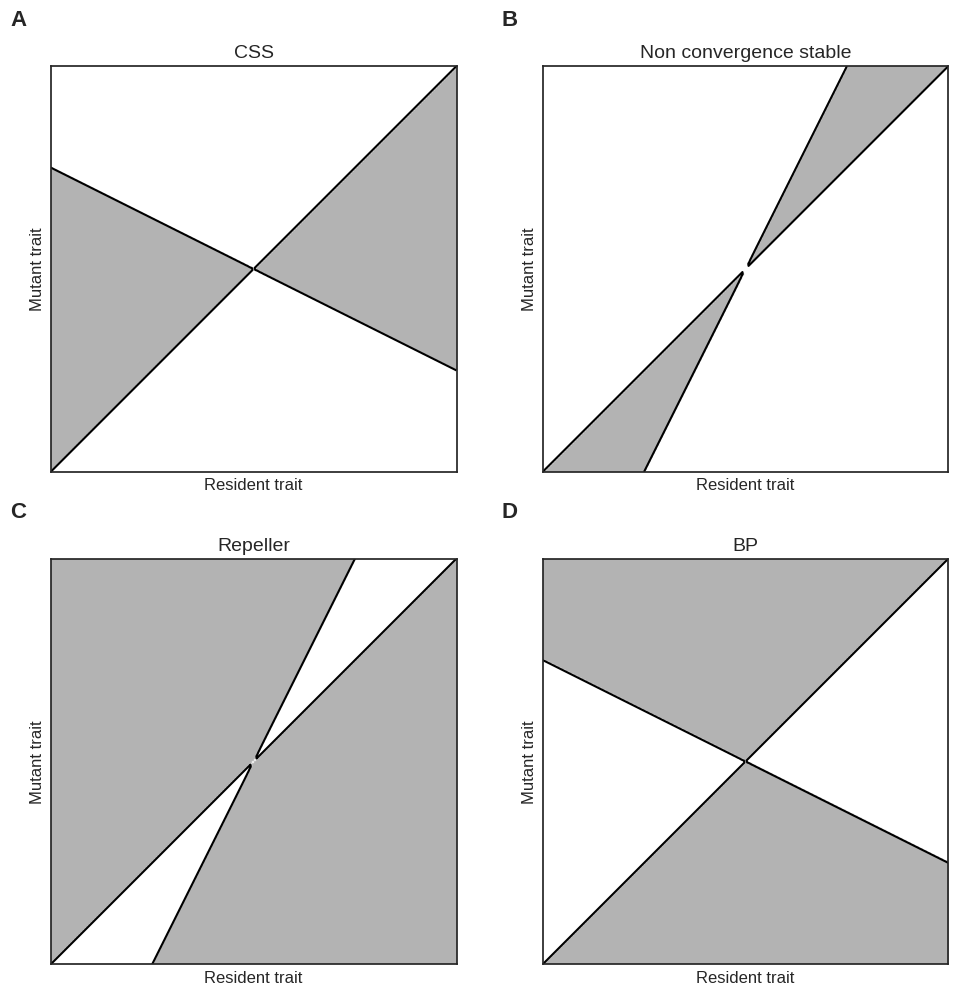

In [ ]:
def plot_pip_panel():
    from matplotlib.gridspec import GridSpec
    a_vals, b_vals = [2, 1/2, -1/2, -2, 2, 1/2, -1/2, -2], [1, 1, 1, 1, -1, -1, -1, -1]
    fig = plt.figure(figsize=(10, 10)); gs = GridSpec(2, 2, figure=fig)
    for i, (pidx, lbl, plbl) in enumerate(zip([7, 5, 1, 3], ['CSS', 'Non convergence stable', 'Repeller', 'BP'], ['A','B','C','D'])):
        ax = fig.add_subplot(gs[i//2, i%2]); xv, yv = np.linspace(0, 1, 200), np.linspace(0, 1, 200); X, Y = np.meshgrid(xv, yv)
        Z = b_vals[pidx-1]*(X - Y)*(a_vals[pidx-1]*(X - 0.5) - (Y - 0.5))
        ax.contour(X, Y, Z, levels=[0], colors='black')
        ax.imshow(Z > 0, extent=[0,1,0,1], origin='lower', cmap='binary', alpha=0.3)
        ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel('Resident trait', fontsize=12); ax.set_ylabel('Mutant trait', fontsize=12); ax.set_title(lbl, fontsize=14)
        ax.text(-0.1, 1.1, plbl, transform=ax.transAxes, fontsize=16, fontweight='bold')
    fig.tight_layout()
    save_fig(fig, resolve_path('Figure_S4.svg'))
    return fig
fig = plot_pip_panel()
display(fig)
plt.close(fig)


## Supplementary Figure S5

Saved: Figure_S5.svg


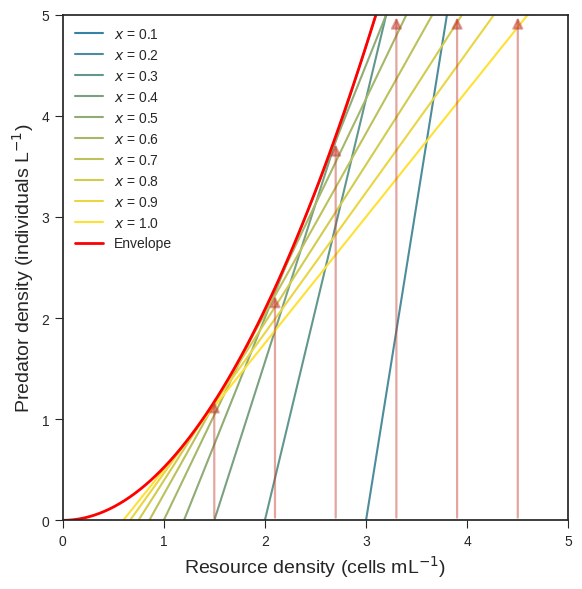

In [ ]:
def plot_figureS5():
    def _cf(c1, c2, mix=0): return mpl.colors.to_hex((1-mix)*np.array(mpl.colors.to_rgb(c1)) + mix*np.array(mpl.colors.to_rgb(c2)))
    _c1, _c2 = '#1f77b4', '#FFE135'; g_s, f_s, e_p_s, c_s, d_s, a_s, n_s = 5, 4, 0.1, 0.1, 0.3, 2, 10; R_s = np.linspace(0.01, 5, 100)
    fig, ax = plt.subplots(figsize=(6, 6))
    for xi in range(1, n_s + 1):
        xv = xi / n_s
        P_vals = (c_s*g_s*R_s*xv - d_s) / (e_p_s*f_s*xv**a_s)
        ax.plot(R_s, P_vals, color=_cf(_c1, _c2, xv), linewidth=1.5, label=f'$x$ = {xv:.1f}')
    R_env = np.linspace(0.01, 5, 100); env = R_env**2 * c_s**2 * g_s**2 / (4 * d_s * (e_p_s * f_s))
    ax.plot(R_env, env, label='Envelope', color='red', linewidth=2)
    for R_val in np.linspace(1.5, 4.5, 6):
        ax.annotate('', xy=(R_val, min(env[np.argmin(np.abs(R_env - R_val))], 5.0)), xytext=(R_val, 0), arrowprops=dict(arrowstyle='-|>', color='#C0392B', lw=1.6, mutation_scale=16, alpha=0.45))
    ax.set_ylim([0, 5]); ax.set_xlim([0, 5]); ax.set_xlabel('Resource density (cells mL$^{-1}$)', fontsize=14); ax.set_ylabel('Predator density (individuals L$^{-1}$)', fontsize=14); ax.legend(fontsize=10); ax.grid(True, linestyle=':', alpha=0.01); ax.set_aspect('equal')
    fig.tight_layout()
    save_fig(fig, resolve_path('Figure_S5.svg'))
    return fig
fig = plot_figureS5()
display(fig)
plt.close(fig)


In [ ]:
import os

# Check the directory structure and look for the saved figures
target_dir = resolve_path('')
print(f'Checking directory: {os.path.abspath(target_dir)}')

if os.path.exists(target_dir):
    files = os.listdir(target_dir)
    if files:
        print(f'Found {len(files)} files in {target_dir}:')
        for f in sorted(files):
            print(f' - {f}')
    else:
        print(f'The directory {target_dir} exists but is empty.')
else:
    print(f'The directory {target_dir} does not exist yet.')

Checking directory: /novos_graficos
Found 18 files in /content/../novos_graficos/:
 - Figure_1.png
 - Figure_1.svg
 - Figure_2.png
 - Figure_2.svg
 - Figure_3.png
 - Figure_3.svg
 - Figure_3_colored.png
 - Figure_3_colored.svg
 - Figure_4.png
 - Figure_4.svg
 - Figure_S2_1.png
 - Figure_S2_1.svg
 - Figure_S2_2.png
 - Figure_S2_2.svg
 - Figure_S4.png
 - Figure_S4.svg
 - Figure_S5.png
 - Figure_S5.svg
